# 02 · EDA de Series Temporales
**Proyecto ML — Bizkaibus 2026**

Análisis exploratorio enfocado en series temporales:
- Tendencia y estacionalidad global
- Distribución por línea
- Tests de estacionariedad (ADF)
- ACF / PACF para calibrar SARIMA
- Impacto visual del subsidio (sept 2022)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

# Carga de datos
df = pd.read_csv('../data/train_merged.csv', parse_dates=['fecha'])
print(f"Dataset cargado: {df.shape}")
df.head(3)


Dataset cargado: (6852, 31)


,año,mes,codigo_linea,linea,viajeros_total,creditrans,gizatrans,gazte_70,goro,ocasional,...,mes_num,año_num,mes_sin,mes_cos,lag_1,lag_3,lag_12,rolling_mean_3,rolling_mean_6,rolling_mean_12
0,2020,1,A3928,ARTEA - ZEBERIO - UGAO MIRABALLES,1999.0,1020.0,725.0,4.0,4.0,167.0,...,1,2020,0.500000,8.660254e-01,NaN,NaN,NaN,NaN,NaN,NaN
1,2020,2,A3928,ARTEA - ZEBERIO - UGAO MIRABALLES,2118.0,1092.0,735.0,11.0,2.0,211.0,...,2,2020,0.866025,5.000000e-01,1999.0,NaN,NaN,NaN,NaN,NaN
2,2020,3,A3928,ARTEA - ZEBERIO - UGAO MIRABALLES,1019.0,542.0,365.0,1.0,3.0,75.0,...,3,2020,1.000000,6.123234e-17,2118.0,NaN,NaN,NaN,NaN,NaN


## 1. Serie global — viajeros totales mensuales

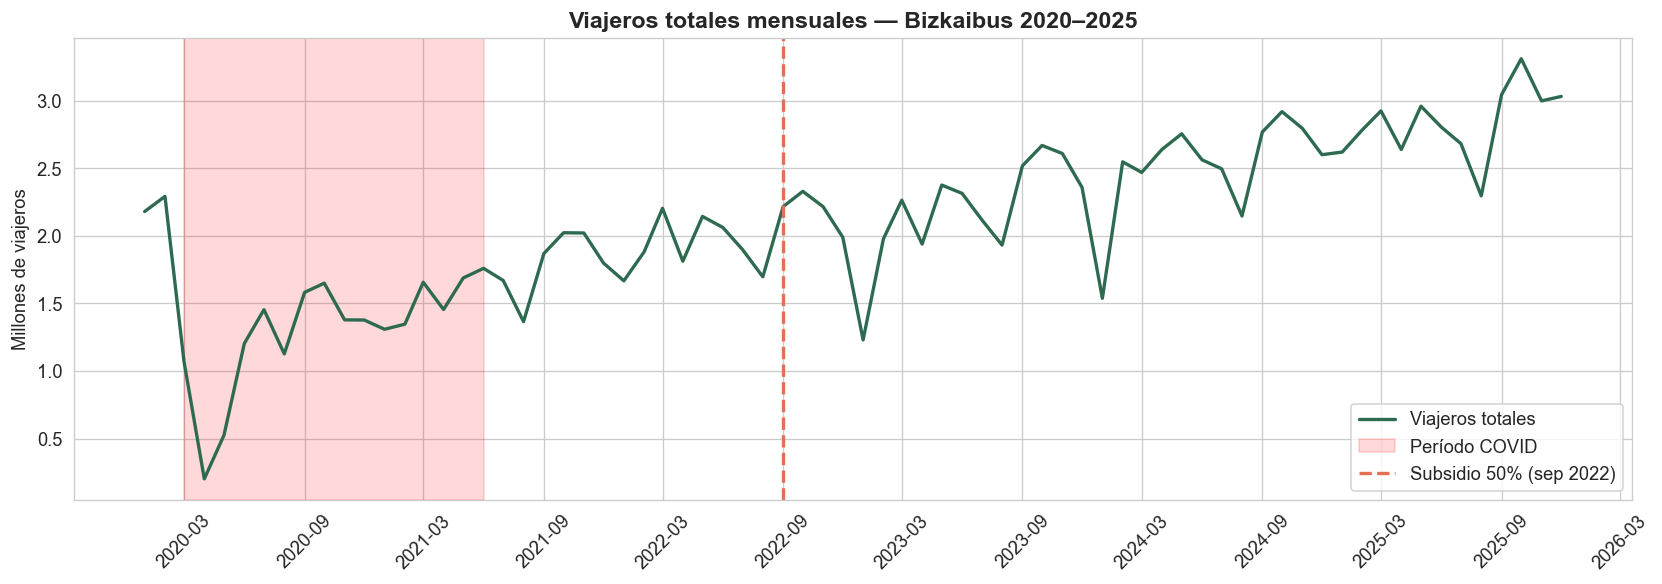

Pico máximo: 2025-10 → 3.31M
Valle mínimo: 2020-04 → 0.20M


In [5]:
# Agregación global mensual
global_mensual = df.groupby('fecha')['viajeros_total'].sum().reset_index()
global_mensual.columns = ['fecha', 'viajeros']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(global_mensual['fecha'], global_mensual['viajeros'] / 1e6, 
        color='#2d6a4f', linewidth=2, label='Viajeros totales')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'), 
           alpha=0.15, color='red', label='Período COVID')
ax.axvline(pd.Timestamp('2022-09-01'), color='#e76f51', linewidth=2, 
           linestyle='--', label='Subsidio 50% (sep 2022)')
ax.set_title('Viajeros totales mensuales — Bizkaibus 2020–2025', fontsize=14, fontweight='bold')
ax.set_ylabel('Millones de viajeros')
ax.set_xlabel('')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()
print("Pico máximo:", global_mensual.loc[global_mensual['viajeros'].idxmax(), 'fecha'].strftime('%Y-%m'), 
      f"→ {global_mensual['viajeros'].max()/1e6:.2f}M")
print("Valle mínimo:", global_mensual.loc[global_mensual['viajeros'].idxmin(), 'fecha'].strftime('%Y-%m'),
      f"→ {global_mensual['viajeros'].min()/1e6:.2f}M")


## 2. Descomposición estacional

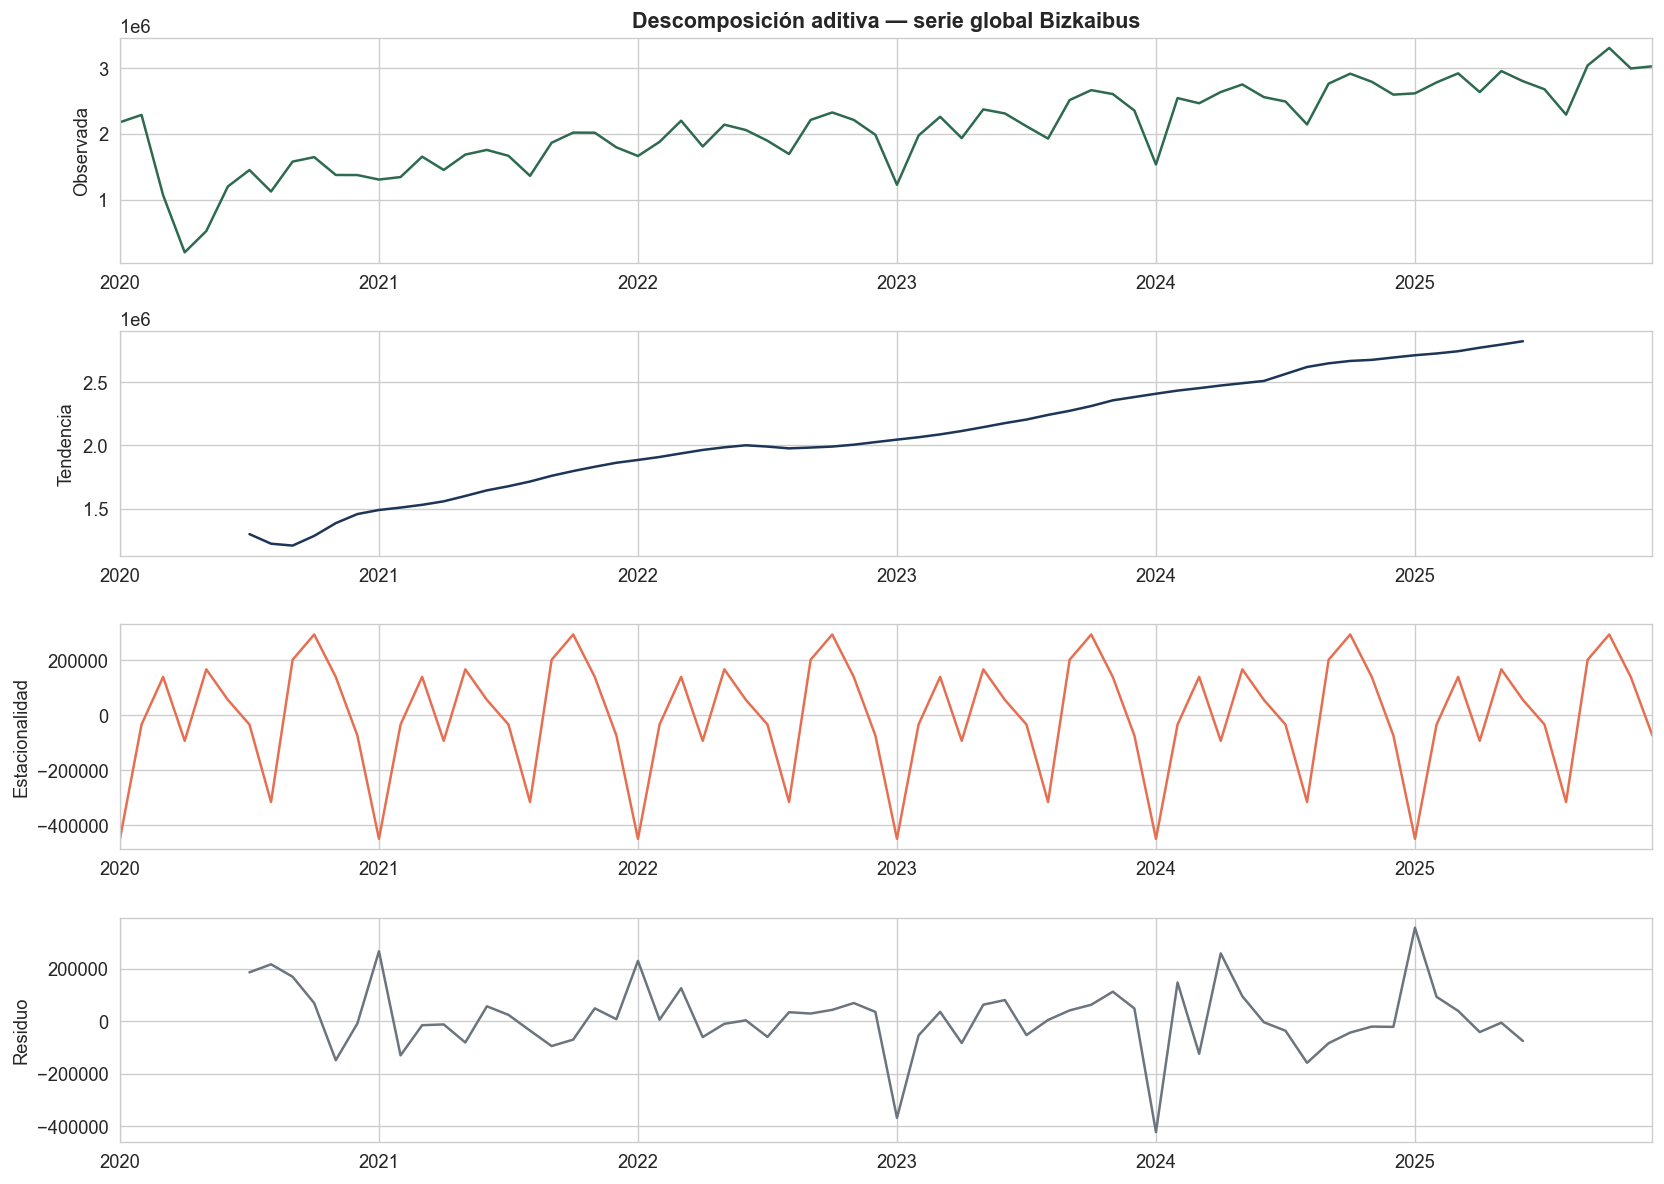

In [4]:
# Descomposición sobre la serie global (sin COVID distorsión: desde 2022)
serie_post = global_mensual.set_index('fecha')['viajeros']
serie_post.index = pd.DatetimeIndex(serie_post.index, freq='MS')

decomp = seasonal_decompose(serie_post, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], color='#2d6a4f'); axes[0].set_ylabel('Observada')
decomp.trend.plot(ax=axes[1], color='#1d3557'); axes[1].set_ylabel('Tendencia')
decomp.seasonal.plot(ax=axes[2], color='#e76f51'); axes[2].set_ylabel('Estacionalidad')
decomp.resid.plot(ax=axes[3], color='#6c757d'); axes[3].set_ylabel('Residuo')
for ax in axes: ax.set_xlabel('')
axes[0].set_title('Descomposición aditiva — serie global Bizkaibus', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 3. Estacionalidad mensual

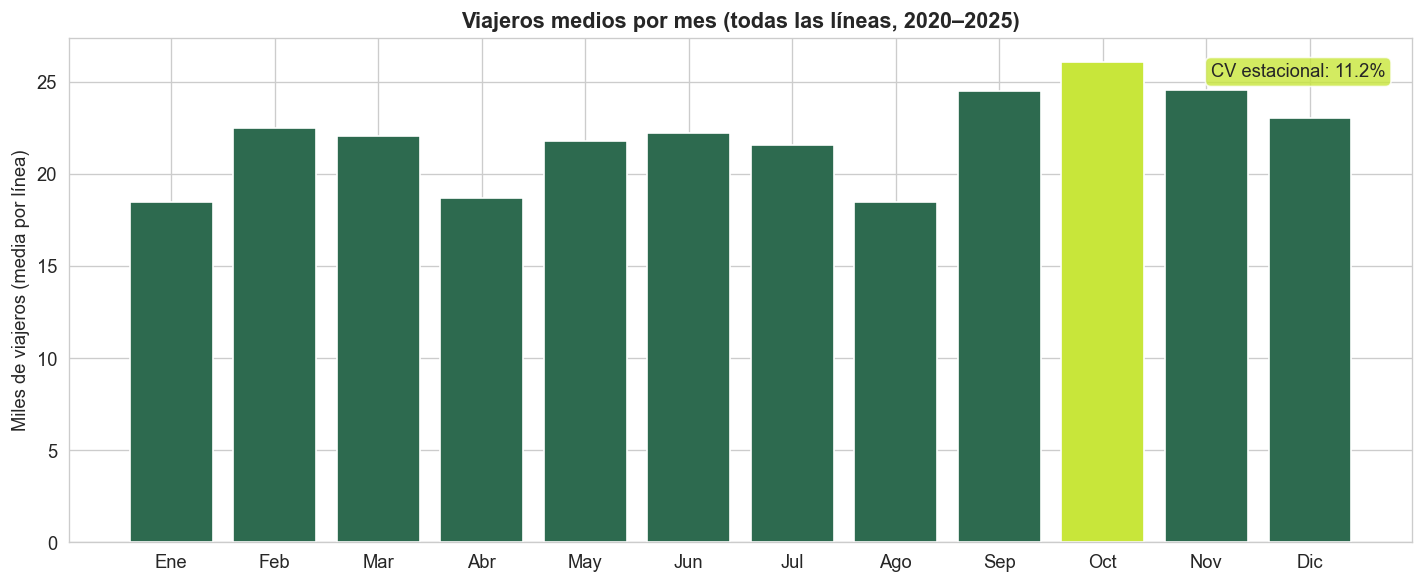

CV estacional: 11.2% → ✓ H2 CONFIRMADA (>10%)


In [8]:
# Patrón estacional promedio por mes
df['mes_nombre'] = df['fecha'].dt.strftime('%b')
meses_orden = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

mensual_avg = df.groupby('mes')['viajeros_total'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(mensual_avg['mes'], mensual_avg['viajeros_total'] / 1e3,
              color=['#c8e63a' if v == mensual_avg['viajeros_total'].max() 
                     else '#2d6a4f' for v in mensual_avg['viajeros_total']])
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
ax.set_title('Viajeros medios por mes (todas las líneas, 2020–2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Miles de viajeros (media por línea)')
cv = mensual_avg['viajeros_total'].std() / mensual_avg['viajeros_total'].mean() * 100
ax.text(0.98, 0.95, f'CV estacional: {cv:.1f}%', transform=ax.transAxes,
        ha='right', va='top', fontsize=11, 
        bbox=dict(boxstyle='round', facecolor='#c8e63a', alpha=0.8))
plt.tight_layout()
plt.show()
print(f"CV estacional: {cv:.1f}% → {'✓ H2 CONFIRMADA (>10%)' if cv > 10 else '✗ H2 no confirmada'}")


## 4. Top líneas y distribución

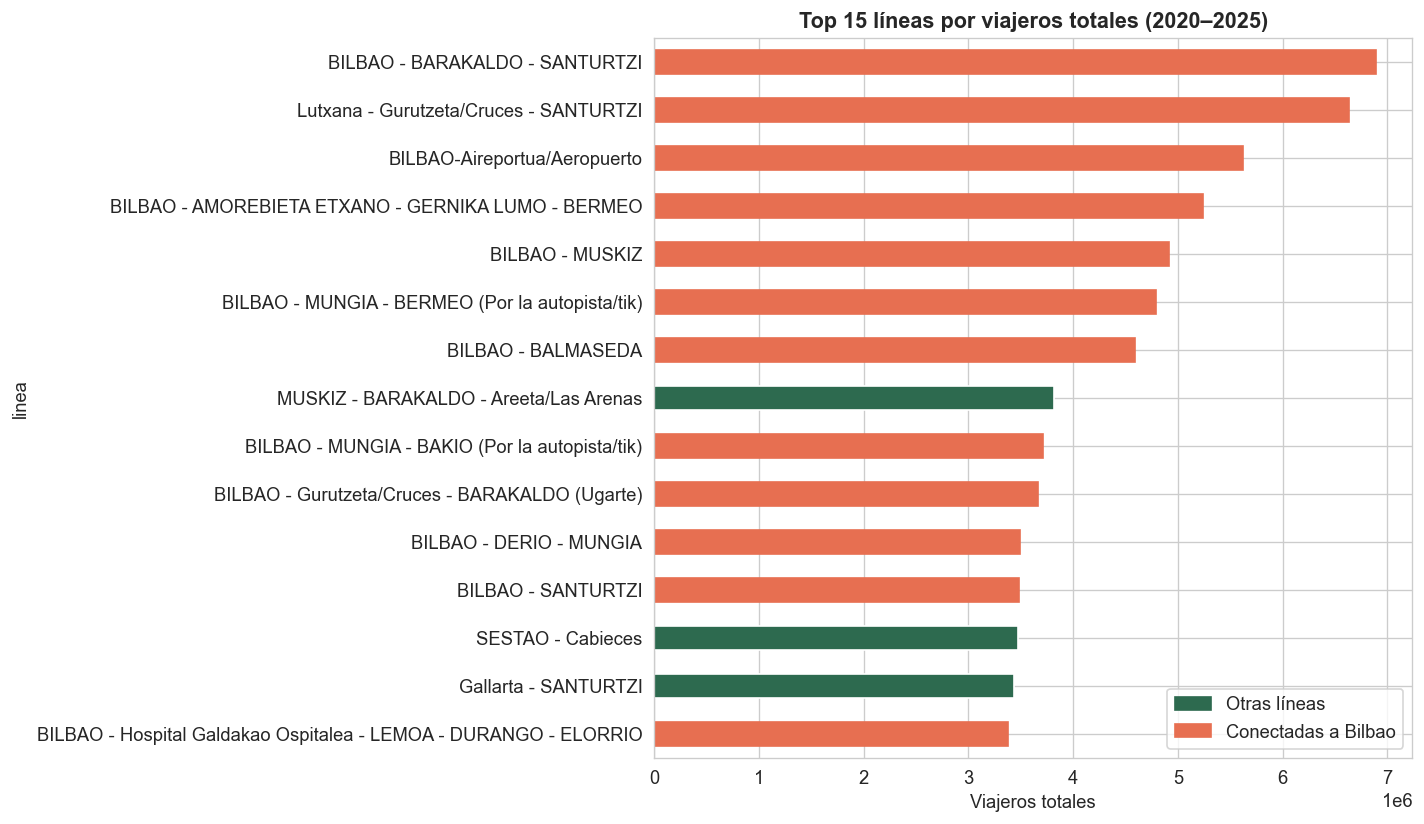

In [10]:
# Top 15 líneas por viajeros totales
top15 = df.groupby('linea')['viajeros_total'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
top15.sort_values().plot(kind='barh', ax=ax, color='#2d6a4f')
ax.set_title('Top 15 líneas por viajeros totales (2020–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Viajeros totales')
# Líneas conectadas a Bilbao en naranja
for i, (linea, v) in enumerate(top15.sort_values().items()):
    if 'BILBAO' in linea.upper() or 'Lutxana' in linea:
        ax.get_children()[i].set_color('#e76f51')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#2d6a4f', label='Otras líneas'),
    plt.Rectangle((0,0),1,1, color='#e76f51', label='Conectadas a Bilbao')
])
plt.tight_layout()
plt.show()


## 5. Test de estacionariedad ADF

In [11]:
# Test ADF en las 10 líneas con más viajeros
top10_lineas = df.groupby('linea')['viajeros_total'].sum().sort_values(ascending=False).head(10).index.tolist()

resultados_adf = []
for linea in top10_lineas:
    serie = df[df['linea'] == linea].sort_values('fecha')['viajeros_total']
    resultado = adfuller(serie.dropna())
    resultados_adf.append({
        'linea': linea[:40],
        'ADF statistic': round(resultado[0], 3),
        'p-value': round(resultado[1], 4),
        'estacionaria': 'Sí' if resultado[1] < 0.05 else 'No'
    })

adf_df = pd.DataFrame(resultados_adf)
print("=== Test Dickey-Fuller Aumentado (ADF) ===")
print(adf_df.to_string(index=False))
print()
print(f"Líneas estacionarias: {(adf_df['estacionaria']=='Sí').sum()} / {len(adf_df)}")
print("→ Las series no estacionarias requerirán diferenciación en SARIMA (d=1)")


=== Test Dickey-Fuller Aumentado (ADF) ===
                                   linea  ADF statistic  p-value estacionaria
          BILBAO - BARAKALDO - SANTURTZI         -0.508   0.8904           No
  Lutxana - Gurutzeta/Cruces - SANTURTZI         -0.819   0.8133           No
            BILBAO-Aireportua/Aeropuerto         -2.830   0.0542           No
BILBAO - AMOREBIETA ETXANO - GERNIKA LUM         -2.706   0.0731           No
                         BILBAO - MUSKIZ         -1.615   0.4755           No
BILBAO - MUNGIA - BERMEO (Por la autopis         -2.041   0.2690           No
                      BILBAO - BALMASEDA         -0.794   0.8209           No
  MUSKIZ - BARAKALDO - Areeta/Las Arenas         -3.806   0.0028           Sí
BILBAO - MUNGIA - BAKIO (Por la autopist         -3.041   0.0312           Sí
BILBAO - Gurutzeta/Cruces - BARAKALDO (U         -1.283   0.6368           No

Líneas estacionarias: 2 / 10
→ Las series no estacionarias requerirán diferenciación en SARIMA (d=

## 6. ACF y PACF — calibración SARIMA

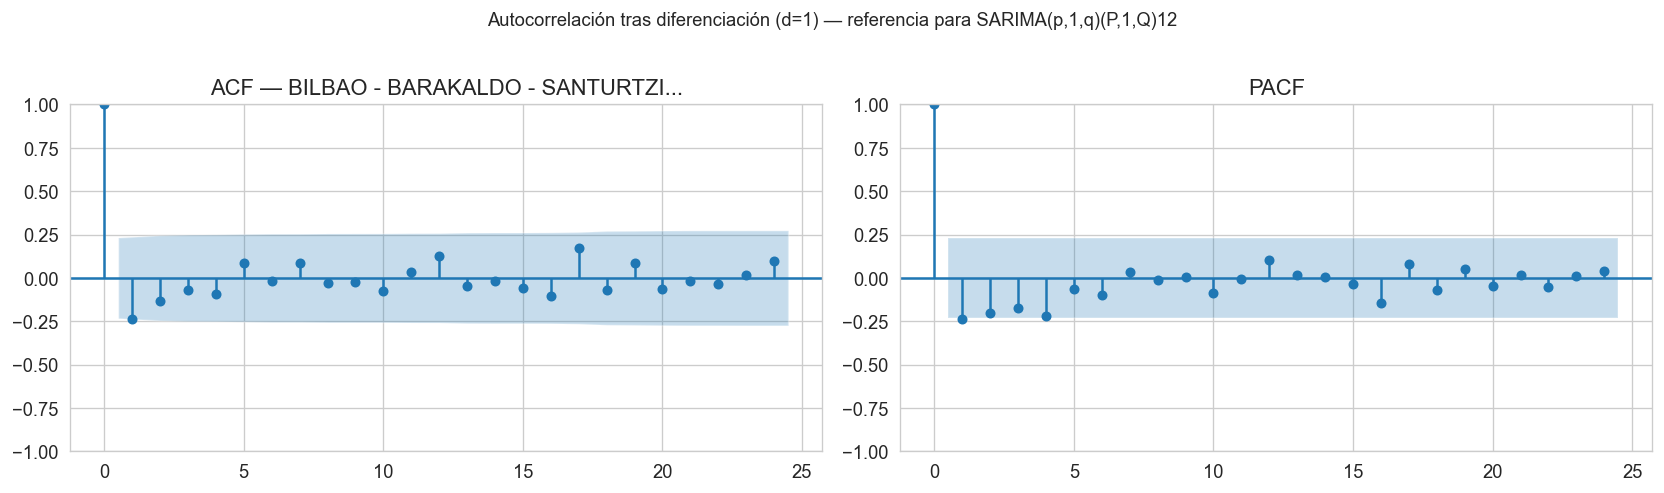

Observaciones para SARIMA:
  - Pico significativo en lag 1 → MA(1) o AR(1)
  - Pico en lag 12 → componente estacional S=12
  → Punto de partida recomendado: SARIMA(1,1,1)(1,1,1)[12]


In [13]:
# ACF/PACF para la línea con más viajeros
linea_ref = top10_lineas[0]
serie_ref = df[df['linea'] == linea_ref].sort_values('fecha').set_index('fecha')['viajeros_total']
serie_ref.index = pd.DatetimeIndex(serie_ref.index, freq='MS')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie_ref.diff().dropna(), lags=24, ax=axes[0], title=f'ACF — {linea_ref[:35]}...')
plot_pacf(serie_ref.diff().dropna(), lags=24, ax=axes[1], title='PACF', method='ywm')
plt.suptitle('Autocorrelación tras diferenciación (d=1) — referencia para SARIMA(p,1,q)(P,1,Q)12',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
print("Observaciones para SARIMA:")
print("  - Pico significativo en lag 1 → MA(1) o AR(1)")
print("  - Pico en lag 12 → componente estacional S=12")
print("  → Punto de partida recomendado: SARIMA(1,1,1)(1,1,1)[12]")
